<a href="https://colab.research.google.com/github/trewto/Machine-Learning-Models/blob/main/Weather_Predict_with_different_model_18_Aug24_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Function of plotting graph**



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y):
    """
    Evaluates the given model on training and testing data, and plots the results.

    Parameters:
    - model: Trained model to evaluate
    - X_train_scaled: Scaled training features
    - X_test_scaled: Scaled testing features
    - y_train: Training target values
    - y_test: Testing target values
    - scaler_y: Scaler used to scale the target values
    """
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Inverse transform the predictions
    y_pred_train = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1))
    y_pred_test = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1))

    # Calculate metrics
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    # Print metrics
    print(f'Training MSE: {mse_train:.2f}, Training MAE: {mae_train:.2f}')
    print(f'Testing MSE: {mse_test:.2f}, Testing MAE: {mae_test:.2f}')

    # Plot predictions vs actual values (Testing set)
    plt.figure(figsize=(6, 3))
    plt.plot(y_test.values, label='Actual')
    plt.plot(y_pred_test, label='Predicted')
    plt.legend()
    plt.title('Actual vs Predicted Precipitation (Testing Set)')
    plt.xlabel('Sample Index')
    plt.ylabel('Precipitation')
    plt.show()

    # Plot predictions vs actual values (Training set)
    plt.figure(figsize=(6, 3))
    plt.plot(y_train.values, label='Actual')
    plt.plot(y_pred_train, label='Predicted')
    plt.legend()
    plt.title('Actual vs Predicted Precipitation (Training Set)')
    plt.xlabel('Sample Index')
    plt.ylabel('Precipitation')
    plt.show()


Reading database

In [ ]:
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2222.csv')
df = pd.read_csv('/content/drive/MyDrive/Projects/Weather/data_set_2.csv')


In [ ]:
df.replace(-999, np.nan, inplace=True)

In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
print((df == -999).sum())


YEAR                   0
MO                     0
DY                     0
HR                     0
T2M                    0
T2MDEW                 0
T2MWET                 0
QV2M                   0
RH2M                   0
PRECTOTCORR            0
PS                     0
WS2M                   0
WD2M                   0
WS10M                  0
WD10M                  0
ALLSKY_SFC_UV_INDEX    0
dtype: int64


In [ ]:
df.head()

,YEAR,MO,DY,HR,T2M,T2MDEW,T2MWET,QV2M,RH2M,PRECTOTCORR,PS,WS2M,WD2M,WS10M,WD10M,ALLSKY_SFC_UV_INDEX
0,2022,1,1,0,14.28,13.73,14.01,9.64,96.38,0.0,101.92,2.17,329.74,3.51,329.67,0.0
1,2022,1,1,1,13.83,13.71,13.77,9.64,99.06,0.0,101.91,2.26,331.75,3.57,331.75,0.0
2,2022,1,1,2,13.44,13.69,13.56,9.58,100.00,0.0,101.89,2.29,333.26,3.57,333.04,0.0
3,2022,1,1,3,13.21,13.65,13.44,9.58,100.00,0.0,101.87,2.23,333.79,3.46,333.72,0.0
4,2022,1,1,4,12.98,13.61,13.30,9.58,100.00,0.0,101.86,1.99,334.44,3.18,334.38,0.0


In [ ]:
#df.fillna(df.mean(), inplace=True)

In [ ]:
# Create lagged features
def create_lagged_features(df, lag=5):
  df_lagged = df.copy()
  for i in range(1, lag + 1):
      df_lagged[f'T2M_lag{i}'] = df_lagged['T2M'].shift(i)
      df_lagged[f'T2MDEW_lag{i}'] = df_lagged['T2MDEW'].shift(i)
      df_lagged[f'T2MWET_lag{i}'] = df_lagged['T2MWET'].shift(i)
      df_lagged[f'RH2M_lag{i}'] = df_lagged['RH2M'].shift(i)
      df_lagged[f'PS_lag{i}'] = df_lagged['PS'].shift(i)
      df_lagged[f'WS2M_lag{i}'] = df_lagged['WS2M'].shift(i)
      df_lagged[f'PRECTOTCORR_lag{i}'] = df_lagged['WD2M'].shift(i)
  df_lagged.dropna(inplace=True)
  return df_lagged

In [ ]:
    # Apply the function
l = 12
df_lagged = create_lagged_features(df, lag=l-1)

# Feature engineering
df_lagged['T2M*QV2M'] = df_lagged['T2M'] * df_lagged['QV2M']
df_lagged['T2M^2'] = df_lagged['T2M'] ** 2
df_lagged['QV2M^2'] = df_lagged['QV2M'] ** 2

lagged_features = [f'T2M_lag{i}' for i in range(1, l)] + \
                      [f'T2MDEW_lag{i}' for i in range(1, l)] + \
                      [f'T2MWET_lag{i}' for i in range(1, l)] + \
                      [f'RH2M_lag{i}' for i in range(1, l)] + \
                      [f'PS_lag{i}' for i in range(1, l)] + \
                      [f'WS2M_lag{i}' for i in range(1, l)]# + \
                     # [f'PRECTOTCORR_lag{i}' for i in range(1, l)]


#features = ['MO', 'DY', 'HR', 'T2M', 'QV2M', 'PS', 'WS10M', 'T2M*QV2M', 'T2M^2', 'QV2M^2'] + lagged_features
#features = ['T2M', 'QV2M', 'PS', 'WS10M', 'T2M*QV2M', 'T2M^2', 'QV2M^2'] + lagged_features
#features = ['HR','T2M*QV2M','T2M^2','QV2M^2','T2M', 'T2MDEW', 'T2MWET', 'QV2M', 'RH2M', 'PS', 'WS2M', 'WD2M', 'WS10M', 'WD10M'] +lagged_features
features = lagged_features

#features = lagged_features

target = 'PRECTOTCORR'

X = df_lagged[features]

y = df_lagged[target]

In [ ]:
X.head()

,T2M_lag1,T2M_lag2,T2M_lag3,T2M_lag4,T2M_lag5,T2M_lag6,T2M_lag7,T2M_lag8,T2M_lag9,T2M_lag10,...,WS2M_lag2,WS2M_lag3,WS2M_lag4,WS2M_lag5,WS2M_lag6,WS2M_lag7,WS2M_lag8,WS2M_lag9,WS2M_lag10,WS2M_lag11
11,17.72,16.68,15.63,14.38,12.66,12.76,12.98,13.21,13.44,13.83,...,2.14,2.30,2.05,1.62,1.78,1.99,2.23,2.29,2.26,2.17
12,19.14,17.72,16.68,15.63,14.38,12.66,12.76,12.98,13.21,13.44,...,2.42,2.14,2.30,2.05,1.62,1.78,1.99,2.23,2.29,2.26
13,21.06,19.14,17.72,16.68,15.63,14.38,12.66,12.76,12.98,13.21,...,2.59,2.42,2.14,2.30,2.05,1.62,1.78,1.99,2.23,2.29
14,22.50,21.06,19.14,17.72,16.68,15.63,14.38,12.66,12.76,12.98,...,2.58,2.59,2.42,2.14,2.30,2.05,1.62,1.78,1.99,2.23
15,22.90,22.50,21.06,19.14,17.72,16.68,15.63,14.38,12.66,12.76,...,2.14,2.58,2.59,2.42,2.14,2.30,2.05,1.62,1.78,1.99


In [ ]:
split_index = int(len(X) * 0.7)  # 70% for training and 30% for testing
#or
# Split the data sequentially
#X_train = X[:split_index]
#X_test = X[split_index:]
#y_train = y[:split_index]
#y_test = y[split_index:]

#X =X[:split_index]
#y = y[:split_index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=900)


In [ ]:
X_train.shape, X_test.shape

((21512, 80), (1133, 80))

In [ ]:
negative_values = y_train[y_train < 0]

In [ ]:

# Step 6: Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


***Trial Error With Different type of MOdel***

**XGB**

In [ ]:
final_model = XGBRegressor(
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=10000,
    subsample=0.5,
    random_state=450
)
final_model.fit(X_train_scaled,  y_train_scaled.ravel())


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10000, n_jobs=None,
             num_parallel_tree=None, random_state=450, ...)

Training MSE: 0.00, Training MAE: 0.00
Testing MSE: 0.14, Testing MAE: 0.17


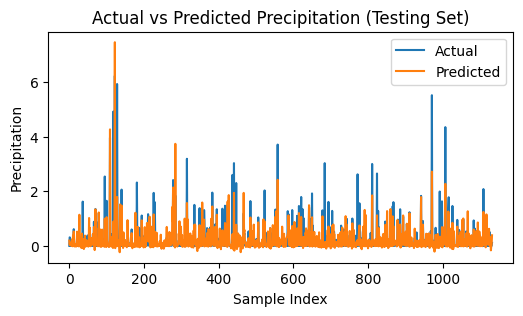

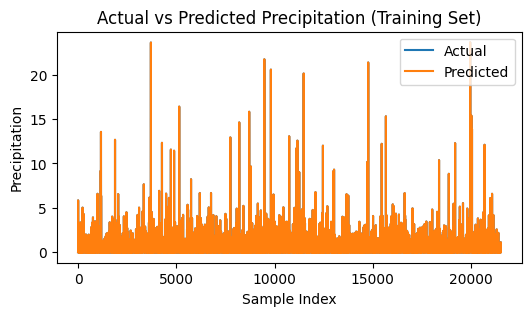

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

RAndomforest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
final_model = RandomForestRegressor(
    max_depth=30,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=41
)

# Fit the model
final_model.fit(X_train_scaled, y_train_scaled.ravel())

RandomForestRegressor(max_depth=30, max_features='log2', min_samples_leaf=4,
                      min_samples_split=10, random_state=41)

Training MSE: 0.16, Training MAE: 0.16
Testing MSE: 0.36, Testing MAE: 0.25


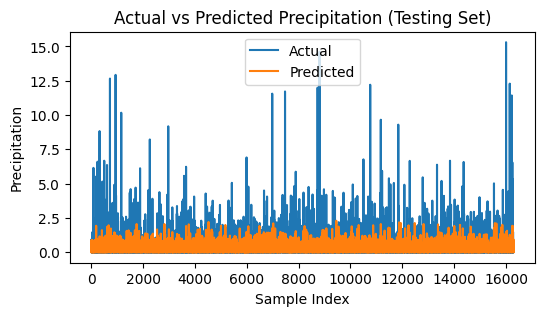

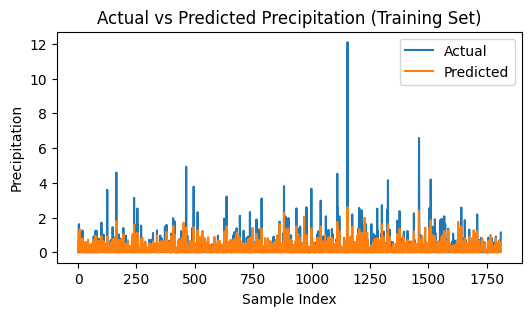

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

final_model = KNeighborsRegressor(n_neighbors=3)  # You can adjust n_neighbors
final_model.fit(X_train_scaled, y_train_scaled.ravel())

KNeighborsRegressor(n_neighbors=3)

Training MSE: 0.15, Training MAE: 0.16
Testing MSE: 0.38, Testing MAE: 0.24


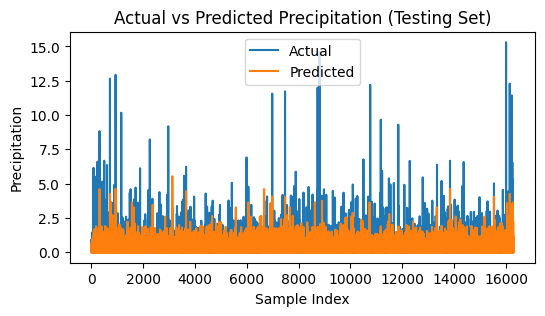

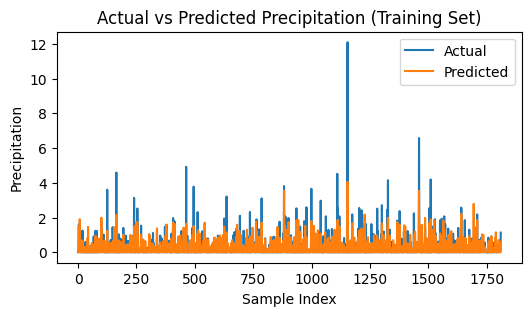

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

SVM

In [ ]:
from sklearn.svm import SVR

final_model = SVR(
    kernel='rbf',          # Radial basis function kernel
    C=1.0,                 # Regularization parameter
    epsilon=0.1            # Epsilon in the epsilon-SVR model
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


SVR()

Training MSE: 0.31, Training MAE: 0.20
Testing MSE: 0.41, Testing MAE: 0.23


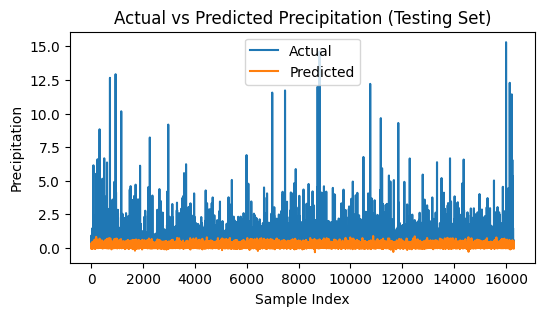

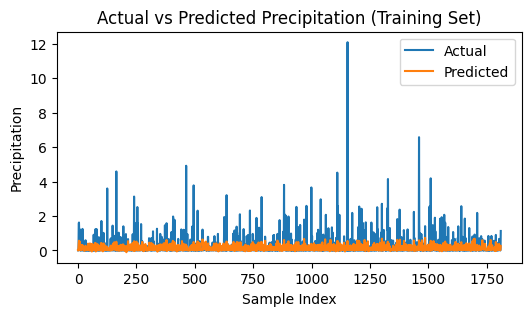

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Lightgbm

In [ ]:
import lightgbm as lgb

final_model = lgb.LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19739
[LightGBM] [Info] Number of data points in the train set: 2264, number of used features: 80
[LightGBM] [Info] Start training from score 0.000000


LGBMRegressor(objective='regression')

Training MSE: 0.22, Training MAE: 0.12
Testing MSE: 0.47, Testing MAE: 0.27


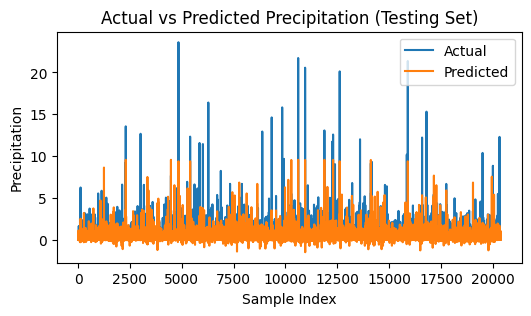

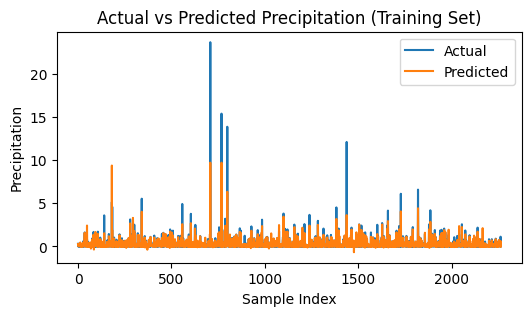

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

 Feedforward Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

final_model = MLPRegressor(
    hidden_layer_sizes=(1000,),   # Single hidden layer with 100 neurons
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=500
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


MLPRegressor(hidden_layer_sizes=(1000,), learning_rate='adaptive',
             max_iter=5000)

Training MSE: 0.14, Training MAE: 0.22
Testing MSE: 0.33, Testing MAE: 0.31


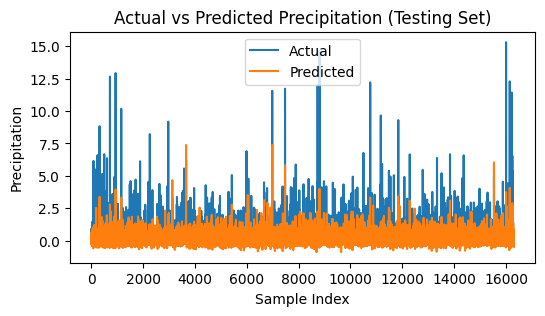

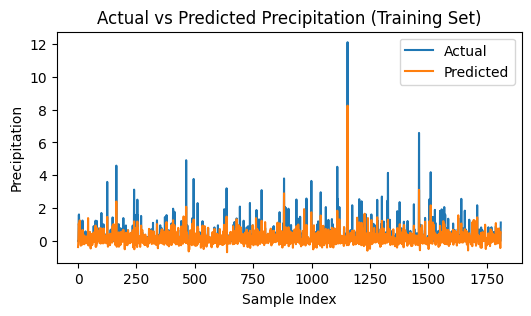

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

final_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=5,
                      random_state=42)

Training MSE: 0.19, Training MAE: 0.18
Testing MSE: 0.46, Testing MAE: 0.28


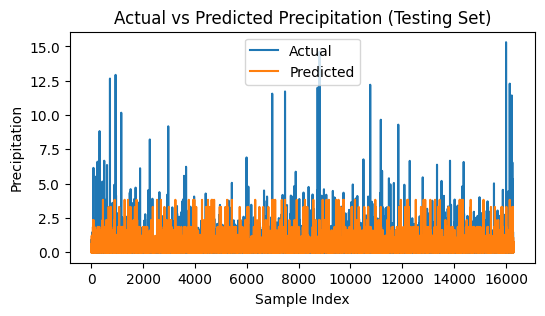

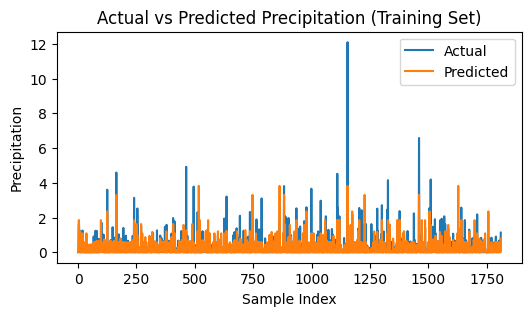

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)

Stacking ensable

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

base_models = [
    ('xgb', XGBRegressor(
        colsample_bytree=0.3,
        learning_rate=0.1,
        max_depth=3,
        n_estimators=300,
        subsample=0.5,
        random_state=45
    )),
    ('rf', RandomForestRegressor(
        max_depth=30,
        max_features='log2',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=100,
        random_state=41
    ))
]

final_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=5
)
final_model.fit(X_train_scaled, y_train_scaled.ravel())


StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.3, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learnin...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=45, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=30,
                                                     max_features='log2',
                                                     min_samples_leaf=4,
                                                     min_samples_split=10,
                                                     random_state=41))],
                  final_estimator=Ridge())

Training MSE: 0.14, Training MAE: 0.16
Testing MSE: 0.36, Testing MAE: 0.25


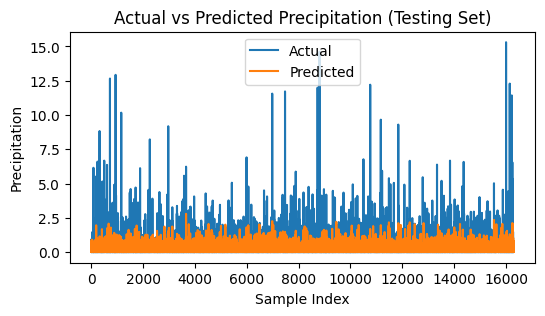

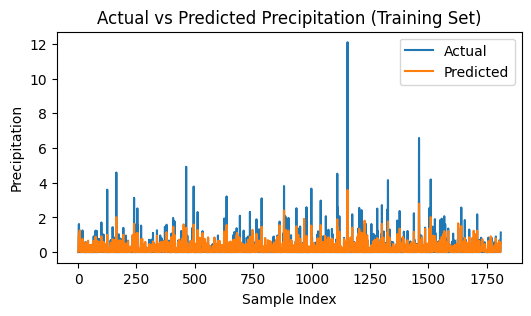

In [ ]:
evaluate_model(final_model, X_train_scaled, X_test_scaled, y_train, y_test, scaler_y)